# Check responsivity to Emotional faces across all (pre)screened contacts for participant
Specifically designed for EmotionTask data <br>

____
**tl;dr** <br>
Group analysis of trial-level HFB reactivity from Emotional Faces task 
- Single-trial activation scalars to assess responsiveness<br>
____
**Prerequisites:** <br>
Files
- *TrialData.csv for each participant (in their EmotionTask folder)<br>

Code
- numpy
- pandas
- matplotlib
- scipy
- my GRID_lab_python repo (https://github.com/jtmiles/GRID_lab_python)


### Imports

In [1]:
# imports
import numpy as np
import pandas as pd
import os
import re
from scipy.signal import find_peaks
import matplotlib.pyplot as plt

from iEEG_utils.loading import read_data
from iEEG_utils.processing import filtering
from iEEG_utils.spike_checks import spike_utils
from iEEG_utils import utils

import statsmodels.api as sm
from statsmodels.stats.weightstats import ttest_ind
from statsmodels.stats.anova import anova_lm
from statsmodels.formula.api import ols

# instantiate a random number generator
rng = np.random.default_rng()

### Load data/metadata

In [2]:
# use file selection dialog to choose folder with data
# Select PARENT folder with *all* emotional faces data
fstr = read_data.select_directory()
print(fstr)

C:\Users\jmile3\OneDrive - SCH\emotional_faces_data


In [3]:
# load ERP_data
os.listdir(fstr)
ID_pat = r'^[A-Za-z0-9]{6}$'
fldr_pat = "EmotionTask"

df_list = []
for ID in os.listdir(fstr):
    if re.fullmatch(ID_pat,ID):
        try:
            loadstr = fstr+"\\"+rf"{ID}\EmotionTask\EmotionTask_{ID}_TrialData.csv"
            df_list.append(pd.read_csv(loadstr, delimiter=","))
        except:
            print(f"Couldn't find data for {ID}")
ERP_df = pd.concat(df_list,ignore_index=True)

Couldn't find data for 542fcb


In [4]:
# add systems identifiers
limbic = ["hip", "amy", "entorhinal","insula","orbit","cingulate"]
assoc = ["supramarginal","middletemporal","inferiortemporal","temporalpole","parietal","frontal","pars"]
sensmo = ["lingual","cuneus","precentral","postcentral","calcarine","fusiform","superiortemporal"]

systems = []
for r in ERP_df.region:
    if any([limbic[ix] in r.lower() for ix in range(len(limbic))]):
        systems.append("limbic")
    # elif any([frontal[ix] in r.lower() for ix in range(len(frontal))]):
    #     systems.append("frontal")
    elif any([assoc[ix] in r.lower() for ix in range(len(assoc))]):
        systems.append("association")
    elif any([sensmo[ix] in r.lower() for ix in range(len(sensmo))]):
        systems.append("sensorimotor")
    else:
        print("?",r)
        systems.append("?")

ERP_df["system"] = systems

In [5]:
ERP_df

,ID,age,region,contacts,trial,amp,latency,duration,keep,system
0,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,0,NaN,NaN,NaN,True,association
1,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,1,3.415308,0.042345,0.019544,True,association
2,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,2,2.424152,0.421498,0.020521,True,association
3,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,3,2.595405,0.223127,0.028339,True,association
4,3882ac,17.58,r_rostralmiddlefrontal,RSS14-RSS13,4,3.151712,0.503583,0.037134,True,association
...,...,...,...,...,...,...,...,...,...,...
21195,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,235,2.415117,0.272964,0.045928,True,limbic
21196,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,236,NaN,NaN,NaN,True,limbic
21197,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,237,NaN,NaN,NaN,False,limbic
21198,ea2142,19.83,r_lateralorbitofrontal,RO_2-RO_1,238,3.388125,0.050163,0.028339,True,limbic


In [6]:
def responsivity(ERP_df):
    '''
    number of non-nan amp trials/number keep trials

    packaging so it can be used in an apply to the df
    '''

    return ERP_df.amp[ERP_df.keep].notna().sum()/ERP_df.keep.sum()

def center(df,var=None):
    '''
    apply mean centering
    var is a string that dictates the column to use
    '''

    return df[var]-df[var].mean()

,df,sum_sq,mean_sq,F,PR(>F)
C(age_cat),1.0,0.000263,0.000263,5.645580,0.019774
C(system),2.0,0.000101,0.000051,1.085133,0.342545
C(age_cat):C(system),2.0,0.000458,0.000229,4.913440,0.009594
Residual,84.0,0.003911,0.000047,NaN,NaN


 p_association = 0.00625505052717987
 p_limbic = 0.2493518750858755
 p_sensorimotor = 0.013485793565775811


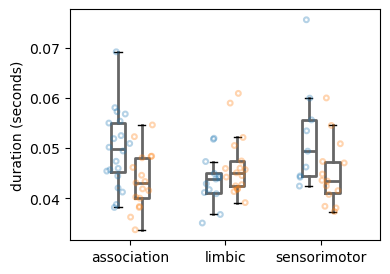

In [25]:
# first things first:
# any reason to think correlations between ERPs and individual trials change with age?

# split dataset into children and adolescents
# categorical ANOVA - System x Age Category
younger = np.array(["69037f","915b69","c66248","65ea6f","a5a41c"])
older = np.array(ERP_df.ID.unique()[~np.isin(ERP_df.ID.unique(),younger)])

ERP_df["age_cat"] = "child"
ERP_df.loc[np.isin(ERP_df.ID,older),"age_cat"]="adolescent"

data = ERP_df.loc[ERP_df.keep,:].groupby(by=["ID","age","contacts","region"]).agg({"amp":"mean","latency":"mean","duration":"mean",
                                                                          "age_cat":"first","system":"first"})
# calculate responsivity for each region, join into `data`
resp_calc = ERP_df.groupby(by=["ID","age","contacts"])[["amp","keep"]].apply(responsivity).rename("responsivity", inplace=True)
data = data.join(resp_calc).reset_index()

var = "duration"

corr_lm = ols(f"{var} ~ C(age_cat) * C(system)", data=data).fit()

anova_tab = anova_lm(corr_lm)
display(anova_tab)

print(f" p_association = {corr_lm.t_test('C(age_cat)[T.child] = 0').pvalue}")
print(f" p_limbic = {corr_lm.t_test('C(age_cat)[T.child]+C(age_cat)[T.child]:C(system)[T.limbic] = 0').pvalue}")
print(f" p_sensorimotor = {corr_lm.t_test('C(age_cat)[T.child]+C(age_cat)[T.child]:C(system)[T.sensorimotor] = 0').pvalue}")

# not useful, only want to look at the pairwise comparisons for each system
# mc = multcomp(ERP_df.R_stat, ERP_df.age_cat+ERP_df.system.to_numpy(), group_order=None)
# print(mc.tukeyhsd(0.05))

dodge = 0.25
labs=[]
plt.figure(figsize=(4,3))
for ii,sys in enumerate(data.system.unique()):
    labs.append(sys)
    child = data.loc[(data.system==sys)&(data.age_cat=="child"),var]
    c_jit = ii-dodge + rng.random(len(child))*(dodge)
    adoles = data.loc[(data.system==sys)&(data.age_cat=="adolescent"),var]
    a_jit = ii + rng.random(len(adoles))*(dodge)
    plt.scatter(c_jit, child, color="C0", s=12, alpha=0.33, lw=1.5, facecolors="none")
    plt.boxplot(positions=[ii-(dodge/2)],x=child, boxprops={"lw":2,"color":[0.4,0.4,0.4]},
               medianprops={"lw":2,"color":[0.4,0.4,0.4]},whiskerprops={"lw":2,"color":[0.4,0.4,0.4]},
               showfliers=False, zorder=0)
    plt.scatter(a_jit, adoles, color="C1", s=12, alpha=0.33, lw=1.5, facecolors="none")
    plt.boxplot(positions=[ii+(dodge/2)],x=adoles, boxprops={"lw":2,"color":[0.4,0.4,0.4]},
               medianprops={"lw":2,"color":[0.4,0.4,0.4]},whiskerprops={"lw":2,"color":[0.4,0.4,0.4]},
               showfliers=False, zorder=0)
plt.ylabel("duration (seconds)")
# plt.ylim([0.4,1.05])
plt.xticks([0,1,2], labels=labs)
plt.show()

association
p = 0.003211800985976495
r^2 = 0.20021270387794754
n = 37.0
t = -3.164169365745895
limbic
p = 0.7191276852013566
r^2 = -0.030855684711239784
n = 30.0
t = 0.363275156309223
sensorimotor
p = 0.1506641604930124
r^2 = 0.05274433353066055
n = 23.0
t = -1.491638840516474


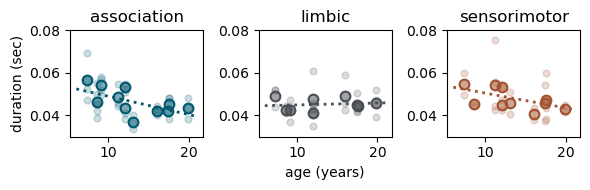

In [32]:
# SCH color palette
dblue = np.array([0, 88, 111])/255
dorange = np.array([162, 82, 48])/255
dgrey = np.array([74, 79, 85])/255
syscol = [dblue,dgrey,dorange]

fig,ax = plt.subplots(1,3,figsize=(6,2),layout="tight")

bins = np.linspace(-0.25,1.05,14)
# bins = np.linspace(0,5,21)

# data = ERP_df.loc[ERP_df.keep,:].groupby(by=["ID","age","contacts"]).agg({"amp":"mean","latency":"mean","duration":"mean",
#                                                                           "age_cat":"first","system":"first"}).reset_index()
var = "duration"
for ix,sys in enumerate(ERP_df.system.unique()):
    # print(sys)
    sysdf = data.loc[(data.system==sys),:].sort_values(by="age")
    subdfs = []
    for ID in sysdf.ID.unique():
        ID_df = sysdf.loc[(sysdf.ID==ID),:]
        subdfs.append(ID_df)
    sysdf = pd.concat(subdfs)
    sysgby = sysdf.groupby(by=["ID","system"]).agg({f"{var}":"mean","age":"mean"})
    
    res = sm.OLS(sysdf[var],sm.add_constant(sysdf.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
    # res = sm.OLS(sysgby[var],sm.add_constant(sysgby.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
    p = res.pvalues["age"]
    print(sys)
    print(f"p = {p}")
    print(f"r^2 = {res.rsquared_adj}")
    print(f"n = {res.nobs}")
    print(f"t = {res.tvalues["age"]}")

    xreg = np.linspace(6,21,16)
    yreg = res.params.const+res.params.age*xreg
    
    ax[ix].scatter(data=sysdf,x="age", y=var, color=syscol[ix], alpha=0.2, s=24)
    ax[ix].scatter(data=sysgby, x="age", y=var, facecolor=np.concat([syscol[ix],(0.5,)]),
                   edgecolor=syscol[ix], lw=1.5, s=49)
    ax[ix].plot(xreg, yreg, color=syscol[ix], linestyle=":", linewidth=2)
    ax[ix].set_title(sys)

if var == "amp":
    [ax[ix].set_ylim([1.25,5.5]) for ix in range(len(ERP_df.system.unique()))]
    ax[0].set_ylabel("magnitude (stdev)")
elif var == "latency":
    [ax[ix].set_ylim([0.18,0.41]) for ix in range(len(ERP_df.system.unique()))]
    ax[0].set_ylabel("latency (sec)")
elif var == "duration":
    [ax[ix].set_ylim([0.03,0.08]) for ix in range(len(ERP_df.system.unique()))]
    ax[0].set_ylabel("duration (sec)")
elif var == "responsivity":
    [ax[ix].set_ylim([0.3,1.1]) for ix in range(len(ERP_df.system.unique()))]

ax[1].set_xlabel("age (years)")
# [ax[ix].set_yticks([]) for ix in range(1,len(ERP_df.system.unique()))]
plt.show()

In [67]:
# take a look at number of comparisons that can be chosen from for each participant/region
gby_df = ERP_df.groupby(by=["ID","age","system","kind"]).agg({"kind":"count","R_stat":"mean","T_stat":"mean"}).sort_values(by=["age","ID"])

In [68]:
gby_df

kind    R_stat    T_stat
ID     age   system       kind                             
69037f 7.33  association  between    48  0.093225  2.245363
                          within     16  0.094113  2.143420
             limbic       between    36  0.139506  3.599829
                          within     12  0.120339  3.101929
             sensorimotor between    24  0.032144  0.935865
                          within      8  0.006323  0.165560
915b69 8.58  association  between    72  0.149866  3.516868
                          within     24  0.145024  3.263454
             limbic       between    24  0.336384  7.708961
                          within      8  0.341608  7.946401
             sensorimotor between    12  0.225518  6.220467
                          within      4  0.232683  6.617994
c66248 9.08  association  between    48  0.160412  3.621304
                          within     16  0.159886  3.557147
             limbic       between    48  0.159211  3.486791
                          within     16  0.161388  3.609959
65ea6f 11.17 association  between    36  0.186381  4.505060
                          within     12  0.184266  4.429509
             sensorimotor between    48  0.131851  3.647020
                          within     16  0.113234  3.228129
a5a41c 12.00 association  between    36  0.019369  0.465248
                          within     12 -0.002800 -0.079369
             limbic       between    48  0.077648  1.642075
                          within     16  0.086519  1.756336
             sensorimotor between    12  0.315293  6.185454
                          within      4  0.314290  6.337136
c25ccc 12.00 association  between    24  0.013015  0.359276
                          within      8  0.019561  0.412897
             limbic       between    48  0.082526  2.109302
                          within     16  0.082170  2.004177
             sensorimotor between    24  0.063969  1.671149
                          within      8  0.089075  2.049604
d5fe6f 13.08 association  between    36  0.207276  4.278837
                          within     12  0.216264  4.785732
             sensorimotor between    24  0.212016  7.496968
                          within      8  0.229260  8.155716
a7ab76 16.00 association  between    48  0.109901  2.480620
                          within     16  0.118283  2.650753
             limbic       between    36  0.138020  3.279914
                          within     12  0.140246  3.355764
             sensorimotor between    24  0.067296  1.768695
                          within      8  0.054196  1.330303
c5ec4c 17.42 association  between    12 -0.011551 -0.338588
                          within      4 -0.009538 -0.344651
             limbic       between    48  0.062496  1.536573
                          within     16  0.062482  1.403384
             sensorimotor between    24  0.135737  3.608248
                          within      8  0.151196  4.254783
3882ac 17.58 association  between    48  0.049502  1.194702
                          within     16  0.061879  1.262376
             limbic       between    24  0.055848  1.224380
                          within      8  0.035498  0.796186
             sensorimotor between    48  0.107245  2.176125
                          within     16  0.102348  2.074761
ea2142 19.83 association  between    36  0.097104  2.033292
                          within     12  0.118291  2.656030
             limbic       between    48  0.096057  2.511009
                          within     16  0.121493  3.291114
             sensorimotor between    24  0.160612  5.110810
                          within      8  0.183430  5.991095

0.98


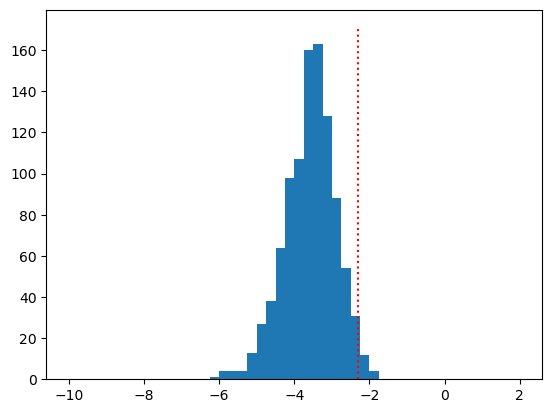

0.996


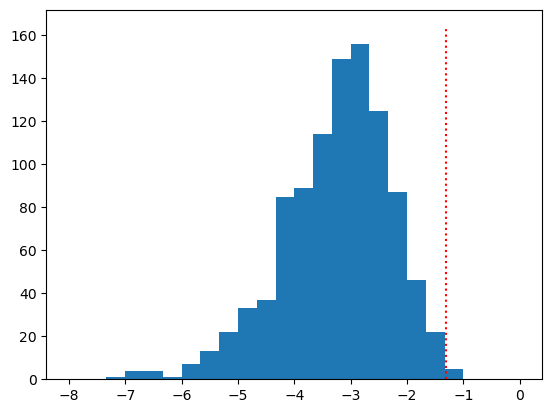

In [70]:
# permutation testing age-dependent correlation significance

bins = np.linspace(-0.25,1.05,14)
# bins = np.linspace(0,5,21)
lts = []
lps = []
iters = 1000
kind = "within"
n_samp = 8
    
for ii in range(iters):
    for ix,sys in enumerate(["limbic"]):
        # print(sys)
        sysdf = ERP_df.loc[(ERP_df.system==sys)&(ERP_df.kind==kind),:].sort_values(by="age")
        subdfs = []
        for ID in sysdf.ID.unique():
            ID_df = sysdf.loc[(sysdf.ID==ID),:]
            subdfs.append(ID_df.sample(n_samp, replace=True))
        sysdf = pd.concat(subdfs)
        sysgby = sysdf.groupby(by=["ID","system"]).agg({"R_stat":"mean","age":"mean"})
        
        res = sm.OLS(sysdf.R_stat,sm.add_constant(sysdf.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
        # res = sm.OLS(sysgby.R_stat,sm.add_constant(sysgby.age),hasconst=True).fit(cov_type="nonrobust",use_t=True)
        lps.append(res.pvalues["age"])
        lts.append(res.tvalues.age)
    
print(sum(np.array(lts)<-2.3)/len(lts))
plt.hist(lts, bins=np.linspace(-10,2,49))
plt.plot(-2.3*np.ones(2),plt.ylim(),"r:")
plt.show()
print(sum(np.log10(lps)<np.log10(0.05))/len(lps))
plt.hist(np.log10(lps), bins=np.linspace(-8,0,25))
plt.plot(np.log10(0.05)*np.ones(2),plt.ylim(),"r:")
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.381
Model:                            OLS   Adj. R-squared:                  0.313
Method:                 Least Squares   F-statistic:                     5.549
Date:                Thu, 02 Jul 2026   Prob (F-statistic):             0.0429
Time:                        14:29:42   Log-Likelihood:                 36.840
No. Observations:                  11   AIC:                            -69.68
Df Residuals:                       9   BIC:                            -68.88
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0196      0.010     -1.982      0.0

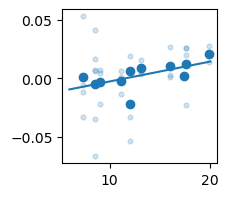

In [50]:
# within-expression correlations greater than between?
test = ERP_df.groupby(by=["ID","region","system","kind"]).agg(
       {"age":"mean","R_stat":"mean","T_stat":"mean"}
        ).sort_values(by=["age","ID","system"]).reset_index()
ltest = test.loc[test.system=="association",:]
ages = []
diffs = []
fig,ax = plt.subplots(figsize=[2,2])
for ID in ltest.ID.unique():
    ages.append(ltest.age[ltest.ID==ID].mean())
    rdiff = ltest.loc[
                     (ltest.ID==ID)&(ltest.kind=="within"),:
                     ].sort_values(by="region").R_stat.to_numpy()-ltest.loc[
                                                                           (ltest.ID==ID)&(ltest.kind=="between"),:
                                                                           ].sort_values(by="region").R_stat.to_numpy()
    ax.scatter(ages[-1]*np.ones(len(rdiff)),rdiff,s=12,color="C0",alpha=0.2,)
    diffs.append(rdiff.mean())
res = sm.OLS(diffs,sm.add_constant(ages),hasconst=True).fit(cov_type="nonrobust",use_t=True)
print(res.summary())
ax.scatter(ages,diffs)
xreg = np.linspace(6,20,15)
yreg = res.params[0]+res.params[1]*xreg
ax.plot(xreg,yreg)

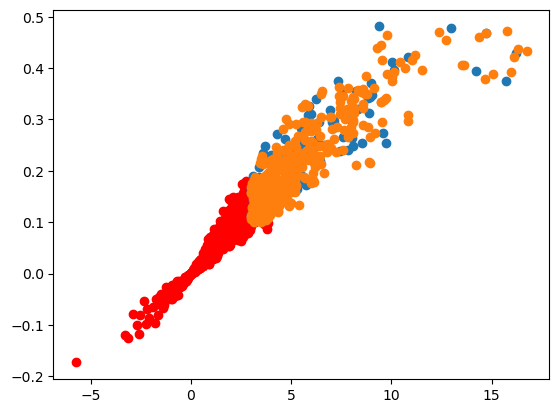

In [30]:
fig,ax = plt.subplots()
ignoring = (ERP_df.T_stat<3) | (ERP_df.R_stat<0.1)
ax.scatter(ERP_df.T_stat[ignoring], ERP_df.R_stat[ignoring], color="r")
ax.scatter(ERP_df.T_stat[~ignoring&(ERP_df.kind=="within")], ERP_df.R_stat[~ignoring&(ERP_df.kind=="within")])
ax.scatter(ERP_df.T_stat[~ignoring&(ERP_df.kind=="between")], ERP_df.R_stat[~ignoring&(ERP_df.kind=="between")])
plt.show()


In [31]:
ERP_df.loc[~ignoring,:]

,ID,age,region,comparison,kind,R_stat,T_stat,system
10,3882ac,17.58,r_rostralmiddlefrontal,happy_happy,within,0.180639,3.289569,association
34,3882ac,17.58,r_lingual,happy_anger,between,0.277644,6.013129,sensorimotor
38,3882ac,17.58,r_lingual,happy_fear,between,0.309889,7.416266,sensorimotor
40,3882ac,17.58,r_lingual,anger_happy,between,0.184721,3.275511,sensorimotor
42,3882ac,17.58,r_lingual,happy_happy,within,0.295293,6.388787,sensorimotor
...,...,...,...,...,...,...,...,...
1351,ea2142,19.83,r_rostralmiddlefrontal,neutral_fear,between,0.362430,7.375101,association
1353,ea2142,19.83,r_rostralmiddlefrontal,fear_happy,between,0.182635,3.158012,association
1355,ea2142,19.83,r_rostralmiddlefrontal,neutral_happy,between,0.250977,5.050291,association
1357,ea2142,19.83,r_rostralmiddlefrontal,fear_neutral,between,0.228569,3.525389,association


In [8]:
import statsmodels.formula.api as smf
corrdf = ERP_df.loc[(ERP_df.variable=='avgcorr'),:].sort_values(by="age")
res = smf.ols('value ~ C(system)*age',data=corrdf, hasconst=True).fit(cov_type="nonrobust", use_t=True)
display(res.summary2())

<class 'statsmodels.iolib.summary2.Summary'>
"""
                      Results: Ordinary least squares
============================================================================
Model:                   OLS                 Adj. R-squared:        0.060   
Dependent Variable:      value               AIC:                   44.4166 
Date:                    2026-06-17 12:20    BIC:                   59.0726 
No. Observations:        85                  Log-Likelihood:        -16.208 
Df Model:                5                   F-statistic:           2.081   
Df Residuals:            79                  Prob (F-statistic):    0.0764  
R-squared:               0.116               Scale:                 0.092246
----------------------------------------------------------------------------
                               Coef.  Std.Err.    t    P>|t|   [0.025 0.975]
----------------------------------------------------------------------------
Intercept                      0.5295   0.1670  3.1709 0.0022  0.1971 0.8619
C(system)[T.limbic]           -0.0875   0.2591 -0.3377 0.7365 -0.6033 0.4283
C(system)[T.sensorimotor]      0.0371   0.2895  0.1282 0.8983 -0.5392 0.6134
age                           -0.0222   0.0127 -1.7500 0.0840 -0.0474 0.0030
C(system)[T.limbic]:age       -0.0011   0.0194 -0.0545 0.9567 -0.0398 0.0376
C(system)[T.sensorimotor]:age  0.0028   0.0208  0.1359 0.8922 -0.0386 0.0442
----------------------------------------------------------------------------
Omnibus:                   9.359           Durbin-Watson:              1.125
Prob(Omnibus):             0.009           Jarque-Bera (JB):           8.776
Skew:                      0.717           Prob(JB):                   0.012
Kurtosis:                  2.350           Condition No.:              158  
============================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is
correctly specified.
"""